In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Model
from sklearn.ensemble import RandomForestRegressor

# Option pour afficher toutes les colonnes
pd.set_option('display.max_columns', None)

## Récupération des données

In [2]:
print("Chargement des données en cours...")
start_time = time.time()

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# Pour y, on s'assure d'avoir un vecteur plat (1D)
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

load_time = time.time() - start_time
print(f"Données chargées en {load_time:.2f} secondes.")
print(f"Dimensions Train : {X_train.shape} | Dimensions Test : {X_test.shape}")

Chargement des données en cours...
Données chargées en 8.76 secondes.
Dimensions Train : (3712444, 13) | Dimensions Test : (928111, 13)


## Stratégie d'entraînement
paramètres équilibrés :
n_estimators=100 : Nombre d'arbres (standard).
max_depth=15 : On limite la profondeur pour éviter que le modèle ne soit trop lourd et ne fasse du sur-apprentissage.
n_jobs=-1 : Crucial, cela utilise tous les cœurs de ton processeur en parallèle.
max_samples=0.1 : (Optionnel) Entraîne chaque arbre sur seulement 10% des données pour aller beaucoup plus vite tout en restant précis.

In [3]:
# Initialisation du modèle
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    n_jobs=-1, 
    random_state=42,
    verbose=1 # Pour voir la progression
)

print("Début de l'entraînement...")
start_train = time.time()

rf_model.fit(X_train, y_train)

end_train = time.time() - start_train
print(f"Entraînement terminé en {end_train/60:.2f} minutes.")

Début de l'entraînement...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 13.4min


Entraînement terminé en 31.84 minutes.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 31.8min finished


##  Prédictions et Métriques de performance

In [4]:
print("Lancement des prédictions sur le jeu de test...")
start_pred = time.time()

# 1. Calcul des prédictions
y_pred = rf_model.predict(X_test)

# 2. Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 3. Calcul de l'erreur moyenne en pourcentage (MAPE)
# On évite la division par zéro en filtrant les y_test nuls si nécessaire
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

end_pred = time.time() - start_pred

print("-" * 30)
print(f"ÉVALUATION DU MODÈLE : RANDOM FOREST")
print("-" * 30)
print(f"R² Score (Précision)    : {r2:.4f}")
print(f"MAE (Erreur moyenne)    : {mae:.2f} €")
print(f"RMSE                    : {rmse:.2f} €")
print(f"MAPE (Erreur en %)      : {mape:.2f} %")
print(f"Temps de prédiction     : {end_pred:.2f} secondes")
print("-" * 30)

Lancement des prédictions sur le jeu de test...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.4s


------------------------------
ÉVALUATION DU MODÈLE : RANDOM FOREST
------------------------------
R² Score (Précision)    : 0.7336
MAE (Erreur moyenne)    : 62172.69 €
RMSE                    : 128489.66 €
MAPE (Erreur en %)      : 34.88 %
Temps de prédiction     : 9.55 secondes
------------------------------


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    8.9s finished


## Analyse de l'importance des variables (Feature Importance)

C:\Users\carine\AppData\Local\Temp\ipykernel_6508\164283068.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


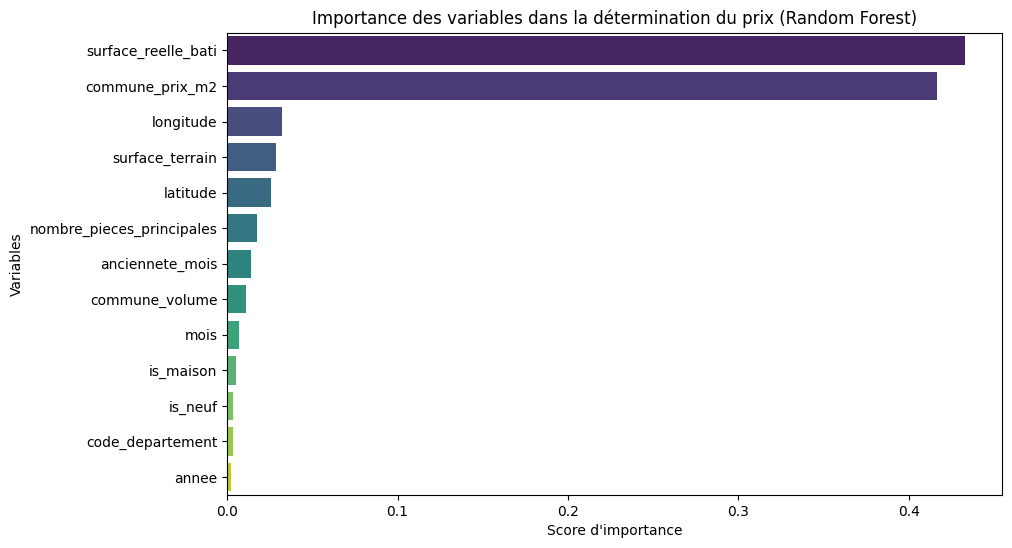

Top 5 des variables les plus importantes :
                Feature  Importance
0   surface_reelle_bati    0.433086
11      commune_prix_m2    0.416487
6             longitude    0.032111
2       surface_terrain    0.028888
7              latitude    0.025909


In [5]:
# Extraction de l'importance des variables
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importance des variables dans la détermination du prix (Random Forest)')
plt.xlabel('Score d\'importance')
plt.ylabel('Variables')
plt.show()

print("Top 5 des variables les plus importantes :")
print(feature_importance_df.head(5))